# Temporal Neural Network for Gold Volatility Regime Forecasting

## Public-release data policy

This notebook is safe to commit only when outputs are cleared.

The notebook keeps **aggregate experimental results** such as model metrics, ROC/PR curves, per-seed scores, confusion matrices, and probability-distribution diagnostics. It suppresses raw or time-indexed Bloomberg-derived data views such as `df.head()`, price charts, return charts, forward-realised-volatility time series, date-indexed prediction paths, and local filesystem paths.

For public GitHub use:

- keep `PUBLIC_RELEASE = True`;
- keep notebook outputs cleared before commit;
- do not commit files under `data/`;
- do not commit `results/predictions_test.csv`;
- do not commit raw-data figures under `results/figures/`.

Run the notebook locally only with your own authorised Bloomberg/parquet data.


## Environment setup

Run the next cell first if the notebook raises `ModuleNotFoundError`. It installs the project requirements into the **same Python interpreter used by this notebook kernel**.


In [1]:
from pathlib import Path
import sys
import subprocess
import importlib.util

def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "requirements.txt").exists() and (p / "tcnvol").exists():
            return p
    # Fallback: common case when running from notebooks/
    if start.name == "notebooks":
        return start.parent
    return start

ROOT = _find_repo_root(Path.cwd())
REQ = ROOT / "requirements.txt"
REQ_BBG = ROOT / "requirements-bloomberg.txt"

#print("Notebook Python kernel detected.")
#print("Repo root detected:", ROOT.name)

required_imports = {
    "numpy": "numpy",
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "statsmodels": "statsmodels",
}

missing = [pkg for pkg, module in required_imports.items() if importlib.util.find_spec(module) is None]

if missing:
    print("Missing packages:", missing)
    if REQ.exists():
        print("Installing from requirements.txt ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(REQ)])
    else:
        print("requirements.txt not found; installing minimal packages directly ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Core requirements already installed.")

# Optional Bloomberg package check. We do not auto-install this unless requirements-bloomberg.txt exists.
if importlib.util.find_spec("blpapi") is None:
    print("blpapi not found. This is fine for parquet mode. For Bloomberg mode, run:")
    print("python -m pip install -r requirements-bloomberg.txt")
else:
    print("blpapi available.")

print("Setup cell complete. If imports still fail, restart the notebook kernel and run again.")


Core requirements already installed.
blpapi available.
Setup cell complete. If imports still fail, restart the notebook kernel and run again.


### Optional Bloomberg API setup

Run the next cell if `DATA_SOURCE = "bloomberg"` or if `DATA_SOURCE = "auto"` and no parquet file exists yet. It installs `blpapi` into this notebook kernel from Bloomberg's package index.


In [2]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("blpapi") is None:
    print("Installing blpapi into this notebook kernel...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--index-url=https://blpapi.bloomberg.com/repository/releases/python/simple/",
        "blpapi",
    ])
else:
    print("blpapi already available in this kernel.")


blpapi already available in this kernel.


## 0. Setup

Run this notebook from either the repository root or from the `notebooks/` folder. The path logic below should detect the repository root automatically.

In [3]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Detect repository root robustly.
CWD = Path.cwd().resolve()
if (CWD / "tcnvol").exists():
    ROOT = CWD
elif (CWD.parent / "tcnvol").exists():
    ROOT = CWD.parent
else:
    raise RuntimeError(
        "Could not locate repository root. Open this notebook from the repo root "
        "or from the notebooks/ folder inside the repo."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook Python kernel detected.")
print("Repo root detected:", ROOT.name)
print("Using data/, results/, and results/figures/ relative to the repo root.")

Notebook Python kernel detected.
Repo root detected: temporal-neural-network
Using data/, results/, and results/figures/ relative to the repo root.


## 1. Configuration

`DATA_SOURCE = "auto"` first tries `data/bloomberg_raw_data.parquet`. If that file is absent, it tries Bloomberg Terminal through `blpapi`.

Set `RUN_TRAINING = True` to reproduce the model run. Training 5 seeds may take several minutes.

In [4]:
# Public-safe defaults.
# Set PUBLIC_RELEASE = False only for local/private research runs.
PUBLIC_RELEASE = True

# Data source:
# - "parquet": load data/bloomberg_raw_data.parquet
# - "bloomberg": fetch from Bloomberg Terminal via blpapi
# - "auto": use parquet if present, otherwise Bloomberg
DATA_SOURCE = "parquet"
DATA_PATH = DATA_DIR / "bloomberg_raw_data.parquet"

# Never cache or export licensed data in public mode.
CACHE_BLOOMBERG_TO_PARQUET = False

# Figures are displayed in-notebook. Saving PNGs is disabled in public mode.
SAVE_FIGURES = False

# Public mode suppresses raw/time-indexed Bloomberg-derived charts and tables.
SHOW_RAW_DATA_VIEWS = not PUBLIC_RELEASE

# Keep aggregate diagnostics/results visible: metrics, ROC/PR, confusion matrices,
# per-seed scores, probability histograms, MP eigenvalue distribution.
SHOW_AGGREGATE_RESULTS = True

TARGET_COL = "PX_LAST XAU Curncy"
WINDOW = 20
HORIZON = 5
LOOKBACK = 252
QUANTILE = 0.75

TRAIN_END = 0.70
VAL_END = 0.85

RUN_TRAINING = True

# Model config. Reduce seeds/epochs for a quick smoke test.
TCN_EPOCHS = 50
TCN_BATCH_SIZE = 64
TCN_PATIENCE = 10
TCN_SEEDS = [1, 2, 3, 4, 5]
TCN_DROPOUT = 0.25

print("DATA_SOURCE:", DATA_SOURCE)
print("DATA_PATH exists:", DATA_PATH.exists())
print("RUN_TRAINING:", RUN_TRAINING)
print("PUBLIC_RELEASE:", PUBLIC_RELEASE)


DATA_SOURCE: parquet
DATA_PATH exists: True
RUN_TRAINING: True
PUBLIC_RELEASE: True


## 2. Import project modules

This imports the local `tcnvol` package from the repository. If this cell fails, make sure the latest bug fixes are committed locally:

- `tcnvol/tcn.py` imports `matrix_expand` and `_glorot`.
- `tcnvol/ensemble.py` imports `pandas as pd`, imports `TCNConfig`, and defines the reusable `evaluate()` helper.

In [5]:
from tcnvol.fracdiff import FracDiff
from tcnvol.rmt import MarchenkoPastur
from tcnvol.features import (
    train_val_test_split,
    build_features,
    build_target,
    align,
    standardisation,
    sliding_windows,
)
from tcnvol.config import TCNConfig
from tcnvol.ensemble import EnsembleTrainer
from tcnvol.har_rv import (
    build_har_features,
    tune_threshold,
    evaluate_binary,
    align_xy,
)

print("Project imports loaded successfully.")

Project imports loaded successfully.


## 3. Helper functions for plotting and diagnostics

In [6]:
def savefig(name: str) -> Path:
    # Save only during local/private runs. Public notebooks should not save
    # Bloomberg-derived rendered figures into results/figures.
    path = FIGURES_DIR / name
    if SAVE_FIGURES and not PUBLIC_RELEASE:
        plt.tight_layout()
        plt.savefig(path, dpi=150, bbox_inches="tight")
    return path


def compute_forward_rv_and_threshold(
    df_raw: pd.DataFrame,
    target_col: str,
    horizon: int = 5,
    lookback: int = 252,
    q: float = 0.75,
) -> pd.DataFrame:
    # Replicate the target-construction components for visual diagnostics.
    r = np.log(df_raw[target_col] / df_raw[target_col].shift(1))
    r2 = r ** 2
    fwd_rv = np.sqrt(252 / horizon * r2.rolling(horizon).sum().shift(-horizon))
    rolling_thr = (
        fwd_rv.shift(horizon)
        .rolling(lookback, min_periods=lookback // 2)
        .quantile(q)
    )
    out = pd.DataFrame({"log_return": r, "fwd_rv": fwd_rv, "threshold": rolling_thr})
    out["regime"] = (out["fwd_rv"] > out["threshold"]).astype(float)
    return out


def print_section(title: str) -> None:
    line = "=" * len(title)
    print(f"\n{title}\n{line}")

## 4. Load data

In `auto` mode, this cell prefers the local parquet cache. If no cache exists, it tries to fetch from Bloomberg Terminal and optionally saves the result to parquet for later runs.

In [7]:
def load_data() -> pd.DataFrame:
    source = DATA_SOURCE.lower().strip()

    if source not in {"auto", "parquet", "bloomberg"}:
        raise ValueError("DATA_SOURCE must be one of: 'auto', 'parquet', 'bloomberg'.")

    use_parquet = source == "parquet" or (source == "auto" and DATA_PATH.exists())
    use_bloomberg = source == "bloomberg" or (source == "auto" and not DATA_PATH.exists())

    if use_parquet:
        if not DATA_PATH.exists():
            raise FileNotFoundError(
                "Parquet file not found under data/. Place your authorised Bloomberg parquet "
                "at data/bloomberg_raw_data.parquet or set DATA_SOURCE='bloomberg'."
            )
        print("Loading authorised parquet from data/ directory.")
        df_loaded = pd.read_parquet(DATA_PATH, engine="pyarrow")

    elif use_bloomberg:
        print("Loading from Bloomberg Terminal via blpapi...")
        try:
            from tcnvol.bloomberg import Bloomberg
        except ModuleNotFoundError as exc:
            raise ModuleNotFoundError(
                "blpapi is not installed in this notebook kernel. "
                "Either set DATA_SOURCE='parquet' and place the file at DATA_PATH, "
                "or run the Optional Bloomberg API setup cell above."
            ) from exc

        bbg = Bloomberg(
            host="localhost",
            port=8194,
            securities=[
                "XAU Curncy",
                "DXY Curncy",
                "LF98TRUU Index",
                "XAG Curncy",
                "NZD Curncy",
                "USGG10YR Index",
                "CL1 Comdty",
            ],
            fields=["PX_LAST", "RSI_14D", "VOLATILITY_30D"],
            start="20060101",
            end="20260101",
        )
        print("Bloomberg request configured.")
        df_loaded = bbg.fetch()

        if CACHE_BLOOMBERG_TO_PARQUET and not PUBLIC_RELEASE:
            df_loaded.to_parquet(DATA_PATH, engine="pyarrow")
            print("Cached Bloomberg data locally under data/ directory.")
        elif CACHE_BLOOMBERG_TO_PARQUET and PUBLIC_RELEASE:
            print("Skipping Bloomberg cache because PUBLIC_RELEASE=True.")

    else:
        raise RuntimeError("Unreachable data-loading branch.")

    df_loaded = df_loaded.ffill(axis=0).dropna(axis=0)
    if TARGET_COL not in df_loaded.columns:
        raise KeyError(
            f"TARGET_COL={TARGET_COL!r} not found. Available columns include: "
            f"{list(df_loaded.columns[:10])}"
        )
    return df_loaded


df = load_data()
print("Loaded data shape:", df.shape)
print("Number of columns:", len(df.columns))

if SHOW_RAW_DATA_VIEWS:
    display(df.head())
else:
    print("Raw data preview suppressed in public-release mode.")


Loading authorised parquet from data/ directory.
Loaded data shape: (5218, 21)
Number of columns: 21
Raw data preview suppressed in public-release mode.


## 5. Data audit

In [8]:
print_section("Data audit")
missing = df.isna().sum().sort_values(ascending=False)
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Total missing values after cleaning:", int(missing.sum()))
print("Columns with missing values after cleaning:", int((missing > 0).sum()))

if SHOW_RAW_DATA_VIEWS:
    display(missing.to_frame("missing_count"))
    print_section("Column summary")
    display(df.describe().T[["mean", "std", "min", "max"]].round(4))
else:
    print("Per-column missing table and descriptive statistics suppressed in public-release mode.")



Data audit
Rows: 5218
Columns: 21
Total missing values after cleaning: 0
Columns with missing values after cleaning: 0
Per-column missing table and descriptive statistics suppressed in public-release mode.


In [9]:
if SHOW_RAW_DATA_VIEWS:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df[TARGET_COL])
    ax.set_title("Gold spot price")
    ax.set_xlabel("Date")
    ax.set_ylabel(TARGET_COL)
    ax.grid(True, alpha=0.3)
    savefig("01_xau_price.png")
    plt.show()
else:
    print("Gold price time-series plot suppressed in public-release mode.")


Gold price time-series plot suppressed in public-release mode.


In [10]:
target_diag = compute_forward_rv_and_threshold(df, TARGET_COL, HORIZON, LOOKBACK, QUANTILE)

if SHOW_RAW_DATA_VIEWS:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(target_diag.index, target_diag["log_return"])
    ax.set_title("Gold daily log returns")
    ax.set_xlabel("Date")
    ax.set_ylabel("Log return")
    ax.grid(True, alpha=0.3)
    savefig("02_xau_log_returns.png")
    plt.show()
else:
    print("Gold return time-series plot suppressed in public-release mode.")


Gold return time-series plot suppressed in public-release mode.


In [11]:
if SHOW_RAW_DATA_VIEWS:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(target_diag.index, target_diag["fwd_rv"], label="Forward realised volatility")
    ax.plot(target_diag.index, target_diag["threshold"], label="Causal rolling 75% threshold")
    ax.set_title("Forward realised volatility target construction")
    ax.set_xlabel("Date")
    ax.set_ylabel("Annualised volatility")
    ax.legend()
    ax.grid(True, alpha=0.3)
    savefig("03_forward_rv_threshold.png")
    plt.show()
else:
    print("Forward-realised-volatility time-series plot suppressed in public-release mode.")


Forward-realised-volatility time-series plot suppressed in public-release mode.


In [12]:
if SHOW_RAW_DATA_VIEWS:
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(target_diag.index, target_diag["regime"])
    ax.set_title("High-volatility regime label")
    ax.set_xlabel("Date")
    ax.set_ylabel("Regime")
    ax.set_yticks([0, 1])
    ax.grid(True, alpha=0.3)
    savefig("04_target_regime.png")
    plt.show()
else:
    valid_regime = target_diag["regime"].dropna()
    print("Target-regime time-series plot suppressed in public-release mode.")
    print("High-volatility regime rate:", round(float(valid_regime.mean()), 4))


Target-regime time-series plot suppressed in public-release mode.
High-volatility regime rate: 0.2503


## 6. Chronological split, fractional differencing, RMT cleaning, and features

In [13]:
# Chronological train/validation/test split: no shuffling.
X_train, X_val, X_test = train_val_test_split(df, TRAIN_END, VAL_END)

print("Split sizes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

if SHOW_RAW_DATA_VIEWS:
    print("X_train:", X_train.index.min(), "→", X_train.index.max())
    print("X_val:  ", X_val.index.min(), "→", X_val.index.max())
    print("X_test: ", X_test.index.min(), "→", X_test.index.max())

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df[TARGET_COL], label=TARGET_COL)
    ax.axvline(X_val.index.min(), linestyle="--", label="Validation start")
    ax.axvline(X_test.index.min(), linestyle="--", label="Test start")
    ax.set_title("Chronological train/validation/test split")
    ax.set_xlabel("Date")
    ax.set_ylabel(TARGET_COL)
    ax.legend()
    ax.grid(True, alpha=0.3)
    savefig("05_train_val_test_split.png")
    plt.show()
else:
    print("Date ranges and price split chart suppressed in public-release mode.")


Split sizes:
Train: (3652, 21)
Validation: (783, 21)
Test: (783, 21)
Date ranges and price split chart suppressed in public-release mode.


In [14]:
# Fractional differencing: fit d on TRAIN only, then transform full series.
fd = FracDiff(tau=1e-4, alpha=0.05)
fd.fit(X_train)

X_all_fd = fd.transform(df)
X_train_fd = fd.transform(X_train)

print("Fractional-differenced full data:", X_all_fd.shape)
print("Fractional-differenced train data:", X_train_fd.shape)

Fractional-differenced full data: (5051, 21)
Fractional-differenced train data: (3485, 21)


In [15]:
# Marchenko-Pastur denoising of train covariance.
mp = MarchenkoPastur()
mp.fit(X_train_fd)
C_clean = mp.C_clean_

print(mp)
print("C_clean shape:", C_clean.shape)

MarchenkoPastur(n=3485, p=21, n_signal=5, lambda_max=1.1613, standardise=True)
C_clean shape: (21, 21)


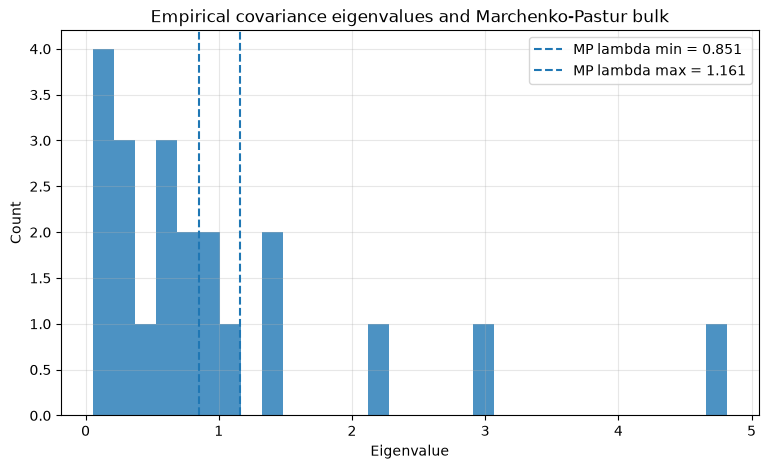

In [16]:
# Visualise empirical train covariance eigenvalues against MP bulk bounds.
X_fd_arr = X_train_fd.to_numpy(dtype=np.float64)
X_fd_arr = X_fd_arr - X_fd_arr.mean(axis=0, keepdims=True)
std = X_fd_arr.std(axis=0, ddof=1, keepdims=True)
std[std == 0] = 1.0
X_fd_arr = X_fd_arr / std
S = (X_fd_arr.T @ X_fd_arr) / X_fd_arr.shape[0]
eigs = np.linalg.eigvalsh(S)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(eigs, bins=30, alpha=0.8)
ax.axvline(mp.lambda_min_, linestyle="--", label=f"MP lambda min = {mp.lambda_min_:.3f}")
ax.axvline(mp.lambda_max_, linestyle="--", label=f"MP lambda max = {mp.lambda_max_:.3f}")
ax.set_title("Empirical covariance eigenvalues and Marchenko-Pastur bulk")
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
savefig("06_mp_eigenvalues.png")
plt.show()

In [17]:
# Build engineered features and target.
X_all_feat = build_features(X_raw=df, X_frac_diff=X_all_fd, window=WINDOW)

X_train_feat = X_all_feat.loc[X_train.index.intersection(X_all_feat.index)]
X_val_feat = X_all_feat.loc[X_val.index.intersection(X_all_feat.index)]
X_test_feat = X_all_feat.loc[X_test.index.intersection(X_all_feat.index)]

y_full = build_target(df, TARGET_COL, horizon=HORIZON, lookback=LOOKBACK, q=QUANTILE)
y_train = y_full.loc[y_full.index.intersection(X_train.index)]
y_val = y_full.loc[y_full.index.intersection(X_val.index)]
y_test = y_full.loc[y_full.index.intersection(X_test.index)]

X_train_feat, y_train = align(X_train_feat, y_train)
X_val_feat, y_val = align(X_val_feat, y_val)
X_test_feat, y_test = align(X_test_feat, y_test)

print("Engineered feature matrix shape:", X_all_feat.shape)
print("Aligned train/validation/test feature shapes:", X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)
print(f"Positive-class rate | train={y_train.mean():.3f}, validation={y_val.mean():.3f}, test={y_test.mean():.3f}")


Engineered feature matrix shape: (5051, 105)
Aligned train/validation/test feature shapes: (3485, 105) (783, 105) (778, 105)
Positive-class rate | train=0.246, validation=0.290, test=0.279


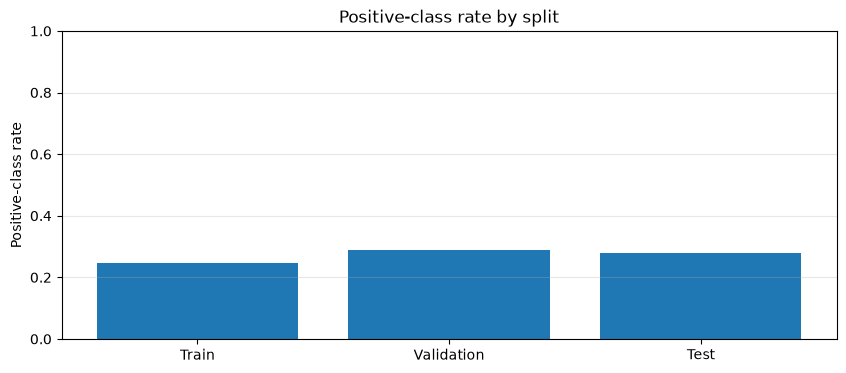

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(["Train", "Validation", "Test"], [y_train.mean(), y_val.mean(), y_test.mean()])
ax.set_title("Positive-class rate by split")
ax.set_ylabel("Positive-class rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
savefig("07_positive_rate_by_split.png")
plt.show()

In [19]:
if SHOW_RAW_DATA_VIEWS:
    # Feature correlation matrix. For readability, use a subset if there are many features.
    max_corr_features = 40
    corr_cols = list(X_train_feat.columns[:max_corr_features])
    corr = X_train_feat[corr_cols].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(corr.values, aspect="auto")
    ax.set_title(f"Feature correlation matrix: first {len(corr_cols)} features")
    ax.set_xticks(np.arange(len(corr_cols)))
    ax.set_yticks(np.arange(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=90, fontsize=6)
    ax.set_yticklabels(corr_cols, fontsize=6)
    fig.colorbar(im, ax=ax)
    savefig("08_feature_correlation_matrix.png")
    plt.show()
else:
    print("Feature correlation matrix suppressed in public-release mode.")


Feature correlation matrix suppressed in public-release mode.


In [20]:
# Standardise based on train only, then create sliding windows.
X_train_z = standardisation(X_train_feat, X_train_feat)
X_val_z = standardisation(X_val_feat, X_train_feat)
X_test_z = standardisation(X_test_feat, X_train_feat)

X_train_w, y_train_w = sliding_windows(X_train_z, y_train, WINDOW)
X_val_w, y_val_w = sliding_windows(X_val_z, y_val, WINDOW)
X_test_w, y_test_w = sliding_windows(X_test_z, y_test, WINDOW)

print("X_train_w:", X_train_w.shape, "| y_train_w:", y_train_w.shape)
print("X_val_w:  ", X_val_w.shape, "| y_val_w:  ", y_val_w.shape)
print("X_test_w: ", X_test_w.shape, "| y_test_w: ", y_test_w.shape)

X_train_w: (3466, 20, 105) | y_train_w: (3466,)
X_val_w:   (764, 20, 105) | y_val_w:   (764,)
X_test_w:  (759, 20, 105) | y_test_w:  (759,)


## 7. Train TCN ensemble and HAR-RV baseline

This cell trains a TCN for each seed, averages the probability outputs, tunes the classification threshold on validation data, and evaluates on the held-out test period.

In [21]:
if RUN_TRAINING:
    cfg = TCNConfig(
        epochs=TCN_EPOCHS,
        batch_size=TCN_BATCH_SIZE,
        patience=TCN_PATIENCE,
        seeds=TCN_SEEDS,
        dropout=TCN_DROPOUT,
    )

    ensemble = EnsembleTrainer(F=X_train_w.shape[2], C_clean=C_clean, cfg=cfg)
    per_seed_metrics = ensemble.fit(X_train_w, y_train_w, X_val_w, y_val_w, X_test_w, y_test_w)
    tcn_metrics_raw = ensemble.evaluate(X_test_w, y_test_w)

    print("TCN ensemble aggregate test metrics:")
    for k, v in tcn_metrics_raw.items():
        if isinstance(v, (int, float, np.floating)):
            print(f"{k}: {float(v):.4f}")
    print(ensemble)
else:
    raise RuntimeError("Set RUN_TRAINING=True to train the ensemble in this notebook.")


pos_weight=3.06  |  positive rate=0.246


SEED 1
  Ep 001 | train=2.4696 | val=2.4828 | AUC=0.5887 | PR-AUC=0.3746 | F1=0.4519 | P=0.3177 | R=0.7822
  Ep 002 | train=1.4189 | val=1.7542 | AUC=0.5835 | PR-AUC=0.3783 | F1=0.4500 | P=0.3363 | R=0.6800
  Ep 003 | train=1.0907 | val=1.8676 | AUC=0.5734 | PR-AUC=0.3625 | F1=0.4537 | P=0.3293 | R=0.7289
  Ep 004 | train=0.8432 | val=1.8052 | AUC=0.5863 | PR-AUC=0.3759 | F1=0.4316 | P=0.3279 | R=0.6311
  Ep 005 | train=0.7370 | val=1.7329 | AUC=0.6232 | PR-AUC=0.4367 | F1=0.4319 | P=0.3588 | R=0.5422
  Ep 006 | train=0.6352 | val=1.5230 | AUC=0.6301 | PR-AUC=0.4513 | F1=0.4553 | P=0.3668 | R=0.6000
  Ep 007 | train=0.5252 | val=1.7779 | AUC=0.6088 | PR-AUC=0.4018 | F1=0.4522 | P=0.3433 | R=0.6622
  Ep 008 | train=0.4752 | val=1.6907 | AUC=0.6389 | PR-AUC=0.4435 | F1=0.4226 | P=0.3672 | R=0.4978
  Ep 009 | train=0.4481 | val=1.5957 | AUC=0.6321 | PR-AUC=0.4317 | F1=0.4518 | P=0.3728 | R=0.5733
  Ep 010 | train=0.4071 | val=1.6552 | AUC=0.6329 |

In [22]:
# HAR-RV logistic-regression baseline.
har_all = build_har_features(df, TARGET_COL)

har_train, y_har_train = align_xy(har_all, y_train)
har_val, y_har_val = align_xy(har_all, y_val)
har_test, y_har_test = align_xy(har_all, y_test)

scaler = StandardScaler()
har_train_z = scaler.fit_transform(har_train)
har_val_z = scaler.transform(har_val)

har_model = LogisticRegression(class_weight="balanced", C=1, max_iter=1000, random_state=42)
har_model.fit(har_train_z, y_har_train)

p_har_val = har_model.predict_proba(har_val_z)[:, 1]
thr_har = tune_threshold(y_har_val.values.astype(int), p_har_val)

print("HAR-RV validation-tuned threshold:", round(thr_har, 4))

HAR-RV validation-tuned threshold: 0.375


In [23]:
# Align HAR-RV and TCN to the same test dates.
tcn_test_index = y_test.index[-len(y_test_w):]
idx_test = har_test.index.intersection(tcn_test_index)

har_test_aligned = har_test.loc[idx_test]
y_test_aligned = y_test.loc[idx_test].values.astype(int)
har_test_aligned_z = scaler.transform(har_test_aligned)
p_har_test = har_model.predict_proba(har_test_aligned_z)[:, 1]

p_tcn_test = ensemble.predict(X_test_w).reshape(-1)
p_tcn_series = pd.Series(p_tcn_test, index=tcn_test_index)
y_tcn_series = pd.Series(np.asarray(y_test_w).astype(int), index=tcn_test_index)

p_tcn_aligned = p_tcn_series.loc[idx_test].values
y_tcn_aligned = y_tcn_series.loc[idx_test].values
thr_tcn = float(ensemble._threshold)

har_metrics = evaluate_binary(y_test_aligned, p_har_test, threshold=thr_har)
tcn_metrics = evaluate_binary(y_tcn_aligned, p_tcn_aligned, threshold=thr_tcn)

comparison = pd.DataFrame({
    "HAR-RV LogReg": har_metrics,
    "TCN Ensemble": tcn_metrics,
}).T

metric_cols = ["AUC", "PR-AUC", "Precision", "Recall", "F1", "BAcc", "Threshold"]
comparison = comparison[metric_cols]

diff = comparison.loc["TCN Ensemble", metric_cols[:-1]] - comparison.loc["HAR-RV LogReg", metric_cols[:-1]]

print("Aligned test observations:", len(idx_test))
display(comparison.round(4))
print("TCN minus HAR-RV:")
display(diff.round(4).to_frame("difference"))

Aligned test observations: 759


,AUC,PR-AUC,Precision,Recall,F1,BAcc,Threshold
HAR-RV LogReg,0.6928,0.4945,0.2886,0.9954,0.4475,0.5097,0.375
TCN Ensemble,0.7278,0.5468,0.3955,0.8148,0.5325,0.6597,0.390


TCN minus HAR-RV:


,difference
AUC,0.0350
PR-AUC,0.0524
Precision,0.1069
Recall,-0.1806
F1,0.0851
BAcc,0.1501


In [24]:
# Save aggregate experiment outputs for README/reuse.
# These aggregate CSVs are acceptable for public GitHub because they do not contain
# date-indexed market data or prediction paths.
per_seed_metrics.to_csv(RESULTS_DIR / "per_seed_metrics.csv", index=False)
comparison.to_csv(RESULTS_DIR / "metrics_summary.csv")

# Keep detailed aligned predictions in memory for aggregate plots only.
# Do not save this CSV in public mode because it is a date-indexed derived series.
predictions_test = pd.DataFrame(
    {
        "y_true": y_test_aligned.astype(int),
        "p_har": p_har_test,
        "p_tcn": p_tcn_aligned,
        "y_pred_har": (p_har_test >= thr_har).astype(int),
        "y_pred_tcn": (p_tcn_aligned >= thr_tcn).astype(int),
    },
    index=idx_test,
)
predictions_test.index.name = "date"

if not PUBLIC_RELEASE:
    predictions_test.to_csv(RESULTS_DIR / "predictions_test.csv")

print("Saved aggregate outputs:")
print("-", "results/per_seed_metrics.csv")
print("-", "results/metrics_summary.csv")

if PUBLIC_RELEASE:
    print("- results/predictions_test.csv suppressed in public-release mode")
else:
    print("-", "results/predictions_test.csv")


Saved aggregate outputs:
- results/per_seed_metrics.csv
- results/metrics_summary.csv
- results/predictions_test.csv suppressed in public-release mode


## 8. Results visualisation

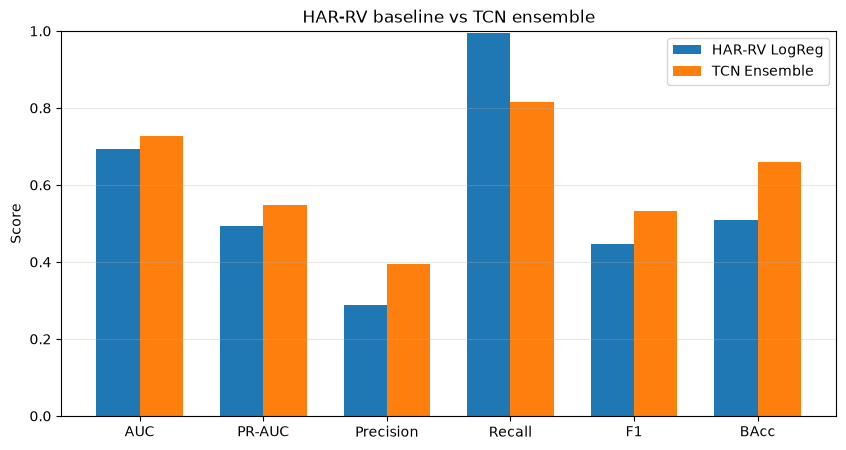

In [25]:
plot_metrics = ["AUC", "PR-AUC", "Precision", "Recall", "F1", "BAcc"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_metrics))
width = 0.35

ax.bar(x - width / 2, comparison.loc["HAR-RV LogReg", plot_metrics], width, label="HAR-RV LogReg")
ax.bar(x + width / 2, comparison.loc["TCN Ensemble", plot_metrics], width, label="TCN Ensemble")

ax.set_title("HAR-RV baseline vs TCN ensemble")
ax.set_xticks(x)
ax.set_xticklabels(plot_metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
savefig("09_model_comparison_bar.png")
plt.show()

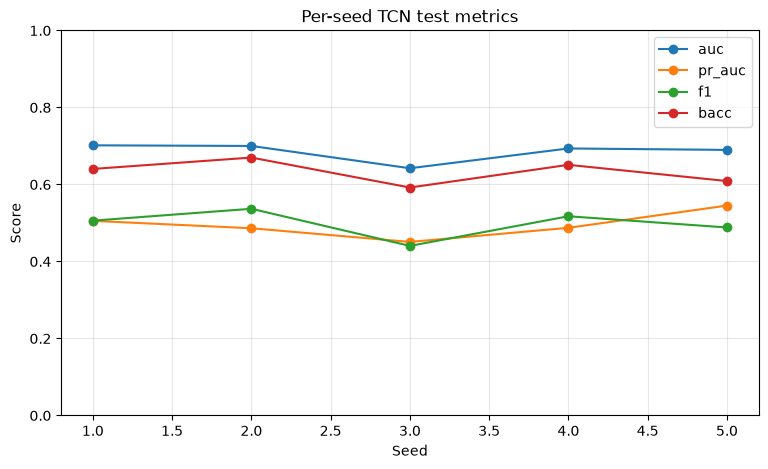

In [26]:
seed_plot_cols = [col for col in ["auc", "pr_auc", "f1", "bacc"] if col in per_seed_metrics.columns]

fig, ax = plt.subplots(figsize=(9, 5))
for metric in seed_plot_cols:
    ax.plot(per_seed_metrics["seed"], per_seed_metrics[metric], marker="o", label=metric)

ax.set_title("Per-seed TCN test metrics")
ax.set_xlabel("Seed")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
savefig("10_per_seed_metrics.png")
plt.show()

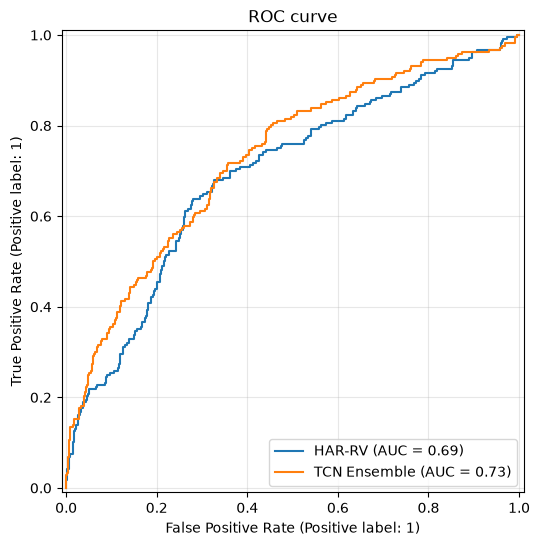

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test_aligned, p_har_test, name="HAR-RV", ax=ax)
RocCurveDisplay.from_predictions(y_tcn_aligned, p_tcn_aligned, name="TCN Ensemble", ax=ax)
ax.set_title("ROC curve")
ax.grid(True, alpha=0.3)
savefig("11_roc_curve.png")
plt.show()

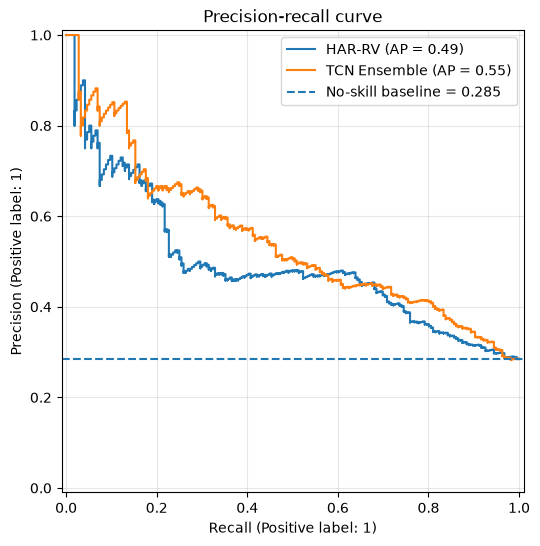

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_test_aligned, p_har_test, name="HAR-RV", ax=ax)
PrecisionRecallDisplay.from_predictions(y_tcn_aligned, p_tcn_aligned, name="TCN Ensemble", ax=ax)
ax.axhline(y_test_aligned.mean(), linestyle="--", label=f"No-skill baseline = {y_test_aligned.mean():.3f}")
ax.set_title("Precision-recall curve")
ax.legend()
ax.grid(True, alpha=0.3)
savefig("12_precision_recall_curve.png")
plt.show()

In [29]:
if SHOW_RAW_DATA_VIEWS:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(predictions_test.index, predictions_test["p_tcn"], label="TCN probability")
    ax.axhline(thr_tcn, linestyle="--", label=f"TCN threshold = {thr_tcn:.3f}")
    ax.scatter(
        predictions_test.index[predictions_test["y_true"] == 1],
        predictions_test.loc[predictions_test["y_true"] == 1, "p_tcn"],
        s=12,
        label="True high-volatility regime",
    )
    ax.set_title("TCN predicted high-volatility probability over test period")
    ax.set_xlabel("Date")
    ax.set_ylabel("Predicted probability")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    savefig("13_tcn_probability_over_time.png")
    plt.show()
else:
    print("Date-indexed probability path suppressed in public-release mode.")


Date-indexed probability path suppressed in public-release mode.


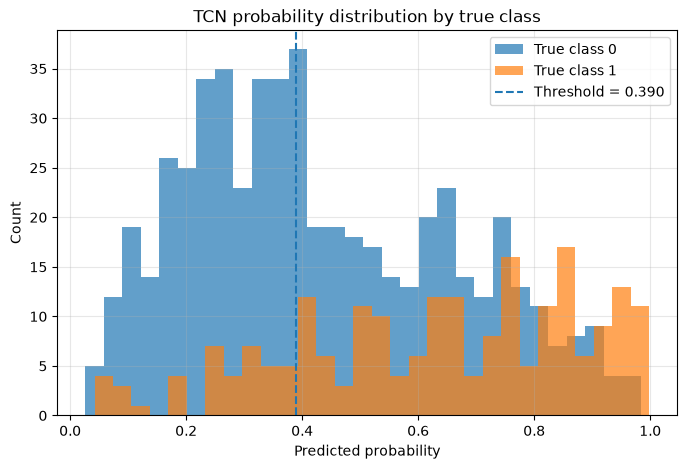

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(predictions_test.loc[predictions_test["y_true"] == 0, "p_tcn"], bins=30, alpha=0.7, label="True class 0")
ax.hist(predictions_test.loc[predictions_test["y_true"] == 1, "p_tcn"], bins=30, alpha=0.7, label="True class 1")
ax.axvline(thr_tcn, linestyle="--", label=f"Threshold = {thr_tcn:.3f}")
ax.set_title("TCN probability distribution by true class")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
savefig("14_probability_histogram_by_class.png")
plt.show()

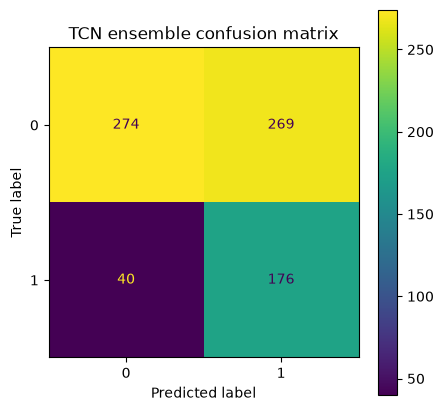

In [31]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    predictions_test["y_true"],
    predictions_test["y_pred_tcn"],
    ax=ax,
    values_format="d",
)
ax.set_title("TCN ensemble confusion matrix")
savefig("15_tcn_confusion_matrix.png")
plt.show()

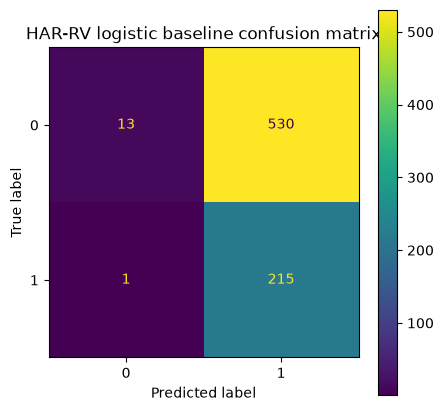

In [32]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    predictions_test["y_true"],
    predictions_test["y_pred_har"],
    ax=ax,
    values_format="d",
)
ax.set_title("HAR-RV logistic baseline confusion matrix")
savefig("16_har_confusion_matrix.png")
plt.show()

## 9. Final interpretation

The main comparison is the TCN ensemble against the HAR-RV logistic-regression baseline on the same aligned test dates.

Use the table above as the headline result. In particular:

- **AUC** and **PR-AUC** compare ranking quality from predicted probabilities.
- **Precision, recall, F1, and balanced accuracy** use thresholds tuned on validation data.
- PR-AUC is especially important because the high-volatility class is a minority class.
- A stronger model should improve PR-AUC, F1, precision, and balanced accuracy without relying only on very high recall.

In [33]:
print_section("Final model comparison")
display(comparison.round(4))

print_section("TCN improvement over HAR-RV")
display(diff.round(4).to_frame("TCN minus HAR-RV"))

print_section("Public-release notes")
print("Kept: aggregate metrics, per-seed scores, ROC/PR curves, probability histograms, and confusion matrices.")
print("Suppressed: raw data previews, price/return/RV time series, date ranges, date-indexed prediction paths, and prediction CSV export.")
print("Remember: clear all outputs before committing the notebook unless you deliberately want to publish only aggregate outputs.")



Final model comparison


,AUC,PR-AUC,Precision,Recall,F1,BAcc,Threshold
HAR-RV LogReg,0.6928,0.4945,0.2886,0.9954,0.4475,0.5097,0.375
TCN Ensemble,0.7278,0.5468,0.3955,0.8148,0.5325,0.6597,0.390



TCN improvement over HAR-RV


,TCN minus HAR-RV
AUC,0.0350
PR-AUC,0.0524
Precision,0.1069
Recall,-0.1806
F1,0.0851
BAcc,0.1501



Public-release notes
Kept: aggregate metrics, per-seed scores, ROC/PR curves, probability histograms, and confusion matrices.
Suppressed: raw data previews, price/return/RV time series, date ranges, date-indexed prediction paths, and prediction CSV export.
Remember: clear all outputs before committing the notebook unless you deliberately want to publish only aggregate outputs.
